# Matching Sersic Profiles to Real Galaxy images

This notebook is a demonstration on how to match Sersic profiles to real galaxy sources using slsim's CatalogSource class. For more details on the matching process, see the README in slsim/Sources/SourceCatalogues/HSTCosmosCatalog and slsim/Sources/SourceCatalogues/CosmosWebCatalog.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

from slsim.Sources.source import Source
from slsim.Deflectors.deflector import Deflector
from slsim.Lenses.lens import Lens
from slsim.ImageSimulation.image_simulation import sharp_image

import warnings

warnings.filterwarnings("ignore")

In [ ]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Catalog: https://zenodo.org/records/19188494
# This directory should contain the catalog and corresponding images
cosmos_web_path = "/home/alhuang/COSMOSWeb_galaxy_catalog"

# Catalog: https://zenodo.org/records/3242143
hst_cosmos_path = "/home/alhuang/COSMOS_23.5_training_sample"

# arbitrary mag zero point
m_zp = 25


# Define a helper function
def simulate_images(source_dict, band):
    source1 = Source(
        extended_source_type="single_sersic",
        cosmo=cosmo,
        **source_dict,
    )
    source2 = Source(
        extended_source_type="catalog_source",
        catalog_path=cosmos_web_path,
        catalog_type="COSMOS_WEB",
        match_n_sersic=False,
        cosmo=cosmo,
        **source_dict,
    )

    source3 = Source(
        extended_source_type="catalog_source",
        catalog_path=hst_cosmos_path,
        catalog_type="HST_COSMOS",
        match_n_sersic=True,
        cosmo=cosmo,
        **source_dict,
    )

    # dummy, zero‑mass deflector
    deflector = Deflector(
        deflector_type="EPL",
        **{
            "z": 0.5,  # keep same redshift
            "theta_E": 0.0,  # zero mass
            "e1_light": 0.0,
            "e2_light": 0.0,
            "e1_mass": 0.0,
            "e2_mass": 0.0,
            "gamma_pl": 2.0,
            "angular_size": 0.05,  # [arcsec] any small value
            "n_sersic": 1.0,  # shape index
            "mag_g": 99.0,
            "mag_r": 99.0,
            "mag_i": 99.0,
            "mag_z": 99.0,
            "mag_y": 99.0,
        },
    )

    lens_class1 = Lens(
        source_class=source1,
        deflector_class=deflector,
        cosmo=cosmo,
    )
    lens_class2 = Lens(
        source_class=source2,
        deflector_class=deflector,
        cosmo=cosmo,
    )

    lens_class3 = Lens(
        source_class=source3,
        deflector_class=deflector,
        cosmo=cosmo,
    )

    pixscale = 0.03
    num_pix = int(source_dict["angular_size"] / pixscale * 4)

    image_list = []

    # simulate source‑only image
    # sersic
    image_list.append(
        sharp_image(
            lens_class=lens_class1,
            band=band,
            mag_zero_point=m_zp,
            num_pix=num_pix,
            delta_pix=pixscale,
            with_source=True,
            with_deflector=False,
        )
    )

    # cosmos web
    image_list.append(
        sharp_image(
            lens_class=lens_class2,
            band=band,
            mag_zero_point=m_zp,
            num_pix=num_pix,
            delta_pix=pixscale,
            with_source=True,
            with_deflector=False,
        )
    )

    # hst cosmos
    image_list.append(
        sharp_image(
            lens_class=lens_class3,
            band=band,
            mag_zero_point=m_zp,
            num_pix=num_pix,
            delta_pix=pixscale,
            with_source=True,
            with_deflector=False,
        )
    )

    lens_classes = [lens_class1, lens_class2, lens_class3]
    return image_list, lens_classes

In [3]:
def plot_images(image_list):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    title = ["Simulated Sersic", "Matched COSMOSWeb", "Matched HST COSMOS"]

    for i in range(len(ax)):
        im = ax[i].imshow(image_list[i], origin="lower")
        ax[i].set_title(title[i])
        plt.colorbar(im, ax=ax[i])

    plt.tight_layout()
    plt.show()

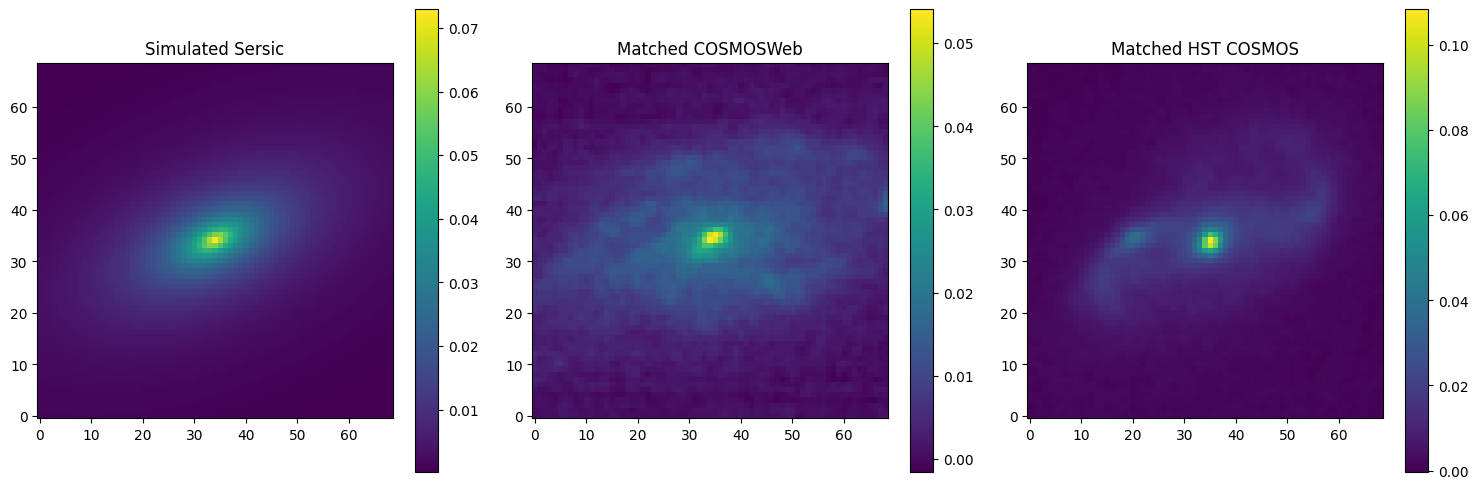

In [4]:
# build source dict for SLSIM
source_dict = {
    "z": 0.5,
    "mag_g": 21.3,
    "mag_r": 21.3,
    "mag_i": 21.3,
    "mag_z": 21.3,
    "mag_y": 21.3,
    "n_sersic": 1.4,
    "angular_size": 0.52,  # arcseconds
    "e1": -0.21697001616620306,
    "e2": 0.240998265256000574,
    "center_x": 0.0,
    "center_y": 0.0,
}

image_list, lens_classes = simulate_images(source_dict, band="g")
plot_images(image_list)

The COSMOSWeb catalog contains images for multiple bands, allowing for wavelength-dependent morphology

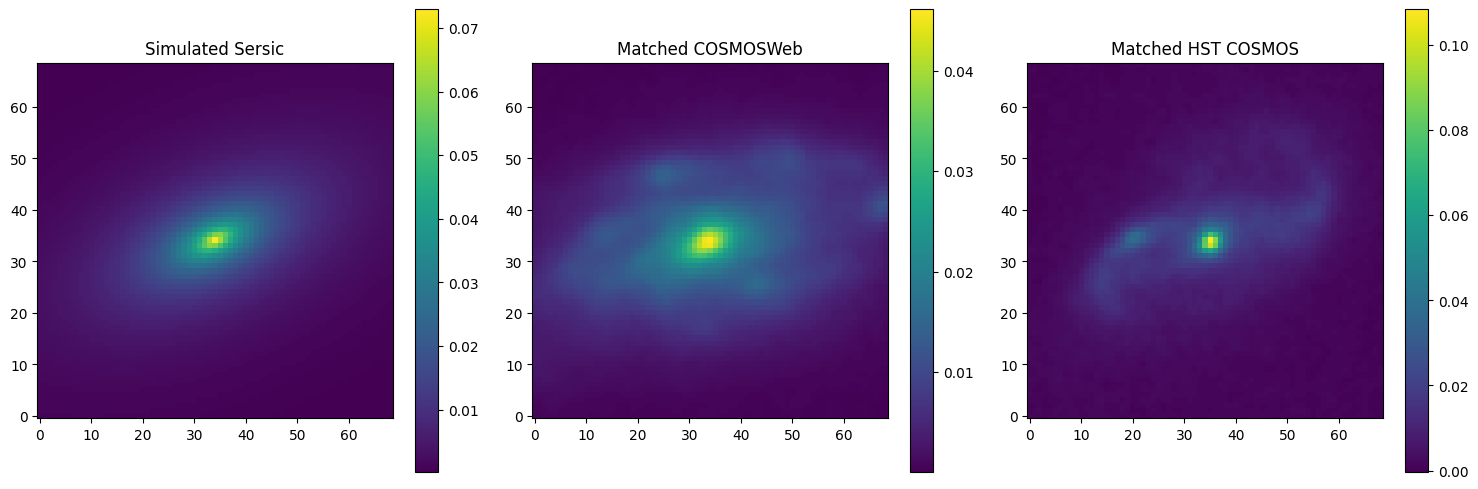

In [5]:
image_list, lens_classes = simulate_images(source_dict, band="z")
plot_images(image_list)

In [6]:
for image in image_list:
    print(np.sum(image))

24.49401967367491
26.55425466460428
25.148741453282742


# Display the properties of the matched sources

In [7]:
# cosmos web
matched_source = lens_classes[1]._source[0]._source.matched_source
matched_source

id,angular_size,sersic_index,sersic_fit_chi2,sersic_angle,axis_ratio,z,physical_size
int64,float64,float64,float64,float64,float64,float64,float64
557765,0.563040903241203,0.6954780728725611,119.76394653320312,-1.084551916275583,0.5118113109901957,0.4501,3.243209177652529


In [8]:
# hst cosmos
matched_source = lens_classes[2]._source[0]._source.matched_source
matched_source

IDENT,GAL_FILENAME,GAL_HDU,PIXEL_SCALE,angular_size,physical_size,axis_ratio,sersic_index,sersic_angle
int32,bytes32,int32,float64,float64,float64,float64,float64,float64
32982,real_galaxy_images_23.5_n52.fits,47,0.029999999329447746,0.6580149953826571,3.215842211349435,0.4982890519933525,1.3368715872191301,1.6166951908142388
